# Embedding Evolution Across Cosmic Time

Track the evolution of the manifold-learning embedding (Dims 1, 2, 3) across redshift using the SubLink merger trees. All earlier-snapshot embeddings are projected into z=0's coordinate system via Nyström projection so the axes are directly comparable.

**Snapshots used:** 99 (z=0), 51 (z≈0.95), 33 (z≈2), 17 (z≈5).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
from scipy.sparse.linalg import eigsh

SNAPS = [17, 33, 51, 99]
REDSHIFTS = {99: 0.0, 51: 0.95, 33: 2.0, 17: 5.0}
H = 0.6774  # TNG cosmology

## Load Embeddings, Progenitors, and Properties

In [2]:
# Load all 4 embeddings
emb = {}
for s in SNAPS:
    d = np.load(f'snapshot{s}_embedding.npz')
    emb[s] = {
        'embedding': d['embedding'],
        'original_index': d['original_index'].astype(int),
        'sorted_neighbors': d['sorted_neighbors'],
    }
    print(f'snap {s}: {emb[s]["embedding"].shape[0]} galaxies')

# Load progenitor matches and properties
prog = pd.read_csv('progenitors_multi.csv')
props = pd.read_csv('progenitor_properties.csv')
print(f'progenitors_multi.csv: {len(prog)} rows')
print(f'progenitor_properties.csv: {len(props)} rows')

snap 17: 2501 galaxies
snap 33: 10000 galaxies
snap 51: 10000 galaxies
snap 99: 10000 galaxies
progenitors_multi.csv: 10000 rows
progenitor_properties.csv: 10000 rows


In [3]:
# Build SubfindID -> embedding-row lookup tables per snapshot
sid_to_row = {s: {int(sid): i for i, sid in enumerate(emb[s]['original_index'])} for s in SNAPS}

# For each z=0 galaxy, find its embedding-row at every snapshot (or -1 if not present)
n_z0 = len(prog)
row_at = {s: np.full(n_z0, -1, dtype=int) for s in SNAPS}
for i, r in prog.iterrows():
    row_at[99][i] = sid_to_row[99].get(int(r['subfind_z0']), -1)
    for s in [51, 33, 17]:
        col = f'subfind_snap_{s}'
        if pd.notna(r[col]):
            row_at[s][i] = sid_to_row[s].get(int(r[col]), -1)

# Mask: z=0 galaxies that have a progenitor present in the embedding at every snapshot
all_present = np.ones(n_z0, dtype=bool)
for s in SNAPS:
    all_present &= (row_at[s] >= 0)
print(f'Galaxies with progenitors in all 4 embeddings: {all_present.sum()} / {n_z0}')

Galaxies with progenitors in all 4 embeddings: 1062 / 10000


## Nyström Projection of Earlier Snapshots into z=0 Space

Use snap 99's centering statistics, eigenvalues, and eigenvectors as the fixed reference frame; project the sorted-neighbor vectors of every other snapshot through it.

In [4]:
# Truncate every snapshot's sorted-neighbor vectors to the smallest common width,
# keeping the LAST columns (which contain the actual neighbor distances).
min_cols = min(emb[s]['sorted_neighbors'].shape[1] for s in SNAPS)
print(f'Truncating all sorted-neighbor vectors to last {min_cols} columns')
sn = {s: emb[s]['sorted_neighbors'][:, -min_cols:] for s in SNAPS}

# Within-snapshot z=0 similarity matrix (using truncated vectors)
D_z0 = euclidean_distances(sn[99])
col_means_z0 = D_z0.mean(axis=0)
grand_mean_z0 = D_z0.mean()
print(f'D_z0 shape: {D_z0.shape}, grand mean: {grand_mean_z0:.3f}')

Truncating all sorted-neighbor vectors to last 2501 columns
D_z0 shape: (10000, 10000), grand mean: 17.957


In [5]:
# Eigendecomposition of double-centered D_z0
k = 10
n = D_z0.shape[0]
C = np.eye(n) - (1 / n) * np.ones((n, n))
B_z0 = -0.5 * C @ D_z0 @ C
evals, evecs = eigsh(B_z0, k=k, which='LA')
order = np.argsort(evals)[::-1]
evals, evecs = evals[order], evecs[:, order]
X_z0 = evecs * np.sqrt(evals)

# Sign-align eigenvectors with the stored embedding
for d in range(k):
    if np.corrcoef(X_z0[:, d], emb[99]['embedding'][:, d])[0, 1] < 0:
        evecs[:, d] *= -1
        X_z0[:, d] *= -1
print(f'Max diff from stored z=0 embedding: {np.abs(X_z0 - emb[99]["embedding"][:, :k]).max():.2e}')

Max diff from stored z=0 embedding: 1.50e-14


In [7]:
# Project every snapshot's sorted-neighbor vectors into z=0 space via Nyström
def nystrom_project(sn_target, sn_z0, col_means, grand_mean, evecs, evals):
    C_cross = euclidean_distances(sn_target, sn_z0)
    row_means = C_cross.mean(axis=1, keepdims=True)
    B_cross = -0.5 * (C_cross - row_means - col_means + grand_mean)
    return B_cross @ evecs / np.sqrt(evals)

X = {99: X_z0}
for s in [51, 33, 17]:
    X[s] = nystrom_project(sn[s], sn[99], col_means_z0, grand_mean_z0, evecs, evals)
    print(f'snap {s} projected: {X[s].shape}')

snap 51 projected: (10000, 10)
snap 33 projected: (10000, 10)
snap 17 projected: (2501, 10)


In [8]:
# Build per-galaxy trajectories: shape (n_tracked, n_snaps, k)
tracked = np.where(all_present)[0]
snaps_ordered = sorted(SNAPS)  # 17, 33, 51, 99
zs = np.array([REDSHIFTS[s] for s in snaps_ordered])
traj = np.empty((len(tracked), len(snaps_ordered), k))
for j, s in enumerate(snaps_ordered):
    rows = row_at[s][tracked]
    traj[:, j, :] = X[s][rows]
print(f'Trajectory tensor: {traj.shape}  (galaxies, snapshots, dims)')

Trajectory tensor: (1062, 4, 10)  (galaxies, snapshots, dims)


## Evolution Plot 1 — Spaghetti, Dim 1 vs Redshift (all tracked galaxies, no stratification)

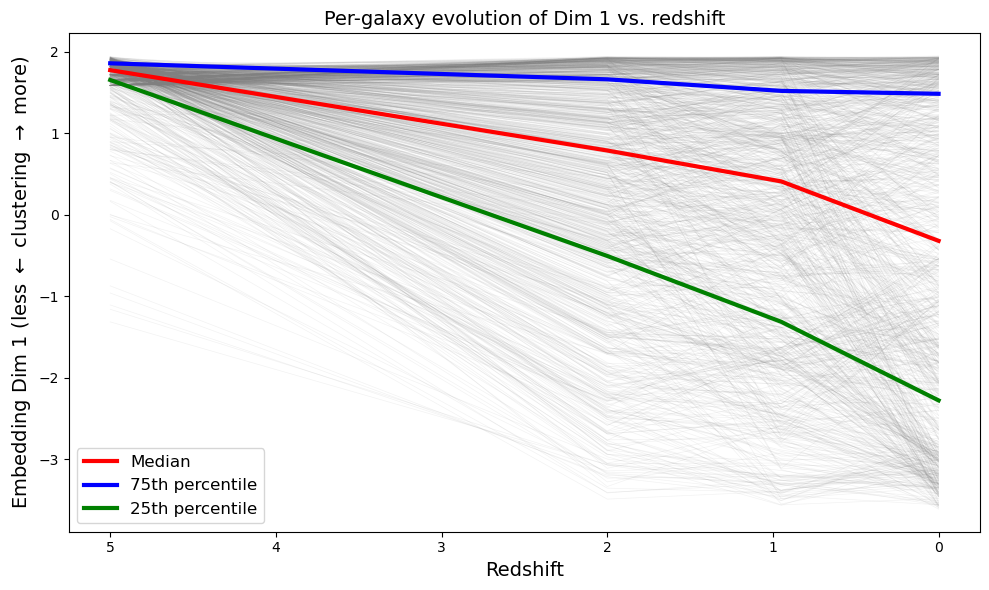

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(len(tracked)):
    ax.plot(zs, traj[i, :, 0], color='gray', alpha=0.1, lw=0.5)
ax.plot(zs, np.median(traj[:, :, 0], axis=0), color='red', lw=3, label='Median')
ax.plot(zs, np.percentile(traj[:, :, 0], 75, axis=0), color='blue', lw=3, label='75th percentile')
ax.plot(zs, np.percentile(traj[:, :, 0], 25, axis=0), color='green', lw=3, label='25th percentile')


ax.invert_xaxis()  # higher z on the left (earlier time)
ax.set_xlabel('Redshift', fontsize=14)
ax.set_ylabel('Embedding Dim 1 (less $\\leftarrow$ clustering $\\rightarrow$ more)', fontsize=14)
ax.set_title('Per-galaxy evolution of Dim 1 vs. redshift', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

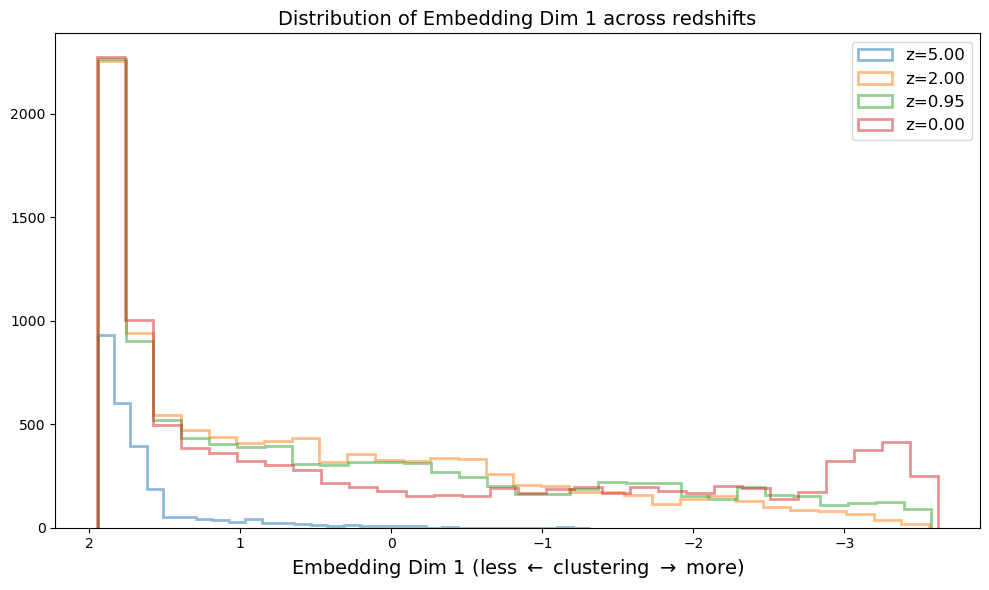

In [18]:
# Plot overlapping histograms of embedding dimension 1 for each redshift slice
fig, ax = plt.subplots(figsize=(10, 6))
for s in snaps_ordered:
    ax.hist(X[s][:, 0], bins=30, alpha=0.5, 
            label=f'z={REDSHIFTS[s]:.2f}', histtype='step', lw=2)
ax.invert_xaxis()  # higher z on the left (earlier time)
ax.set_xlabel('Embedding Dim 1 (less $\\leftarrow$ clustering $\\rightarrow$ more)', fontsize=14)
ax.set_title('Distribution of Embedding Dim 1 across redshifts', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()


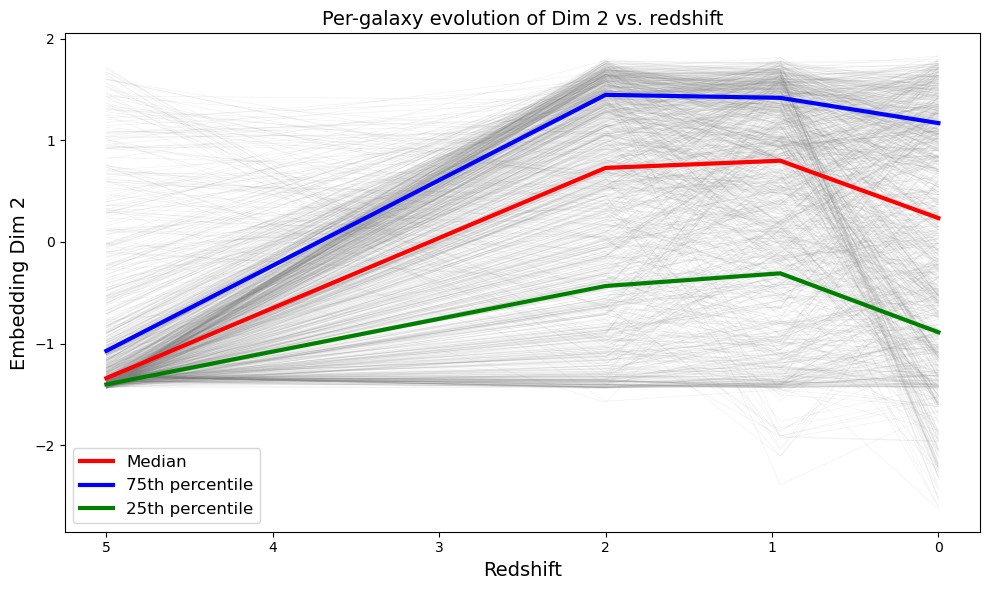

In [28]:
# Make spaghetti plot for embedding dim 2 vs. redshift
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(len(tracked)):
    ax.plot(zs, traj[i, :, 1], color='gray', alpha=0.1, lw=0.5)
ax.plot(zs, np.median(traj[:, :, 1], axis=0), color='red', lw=3, label='Median')
# plot 25th and 75th percentiles
ax.plot(zs, np.percentile(traj[:, :, 1], 75, axis=0), color='blue', lw=3, label='75th percentile')
ax.plot(zs, np.percentile(traj[:, :, 1], 25, axis=0), color='green', lw=3, label='25th percentile')


ax.invert_xaxis()  # higher z on the left (earlier time)
ax.set_xlabel('Redshift', fontsize=14)
ax.set_ylabel('Embedding Dim 2', fontsize=14)
ax.set_title('Per-galaxy evolution of Dim 2 vs. redshift', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

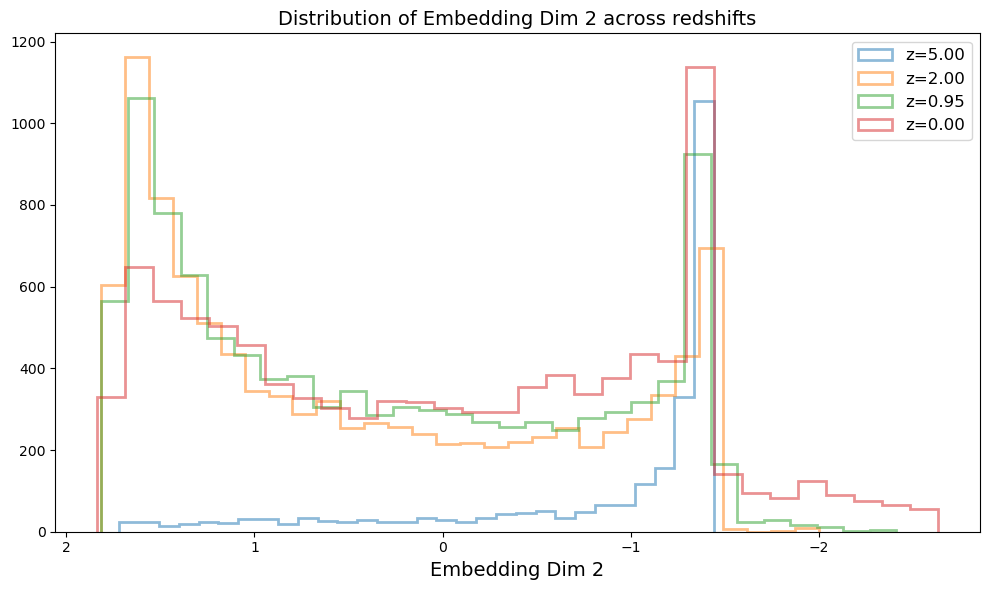

In [31]:
# Plot overlapping histograms of embedding dimension 2 for each redshift slice
fig, ax = plt.subplots(figsize=(10, 6))
for s in snaps_ordered:
    ax.hist(X[s][:, 1], bins=30, alpha=0.5, 
            label=f'z={REDSHIFTS[s]:.2f}', histtype='step', lw=2)
ax.invert_xaxis()  # higher z on the left (earlier time)
ax.set_xlabel('Embedding Dim 2', fontsize=14)
ax.set_title('Distribution of Embedding Dim 2 across redshifts', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()


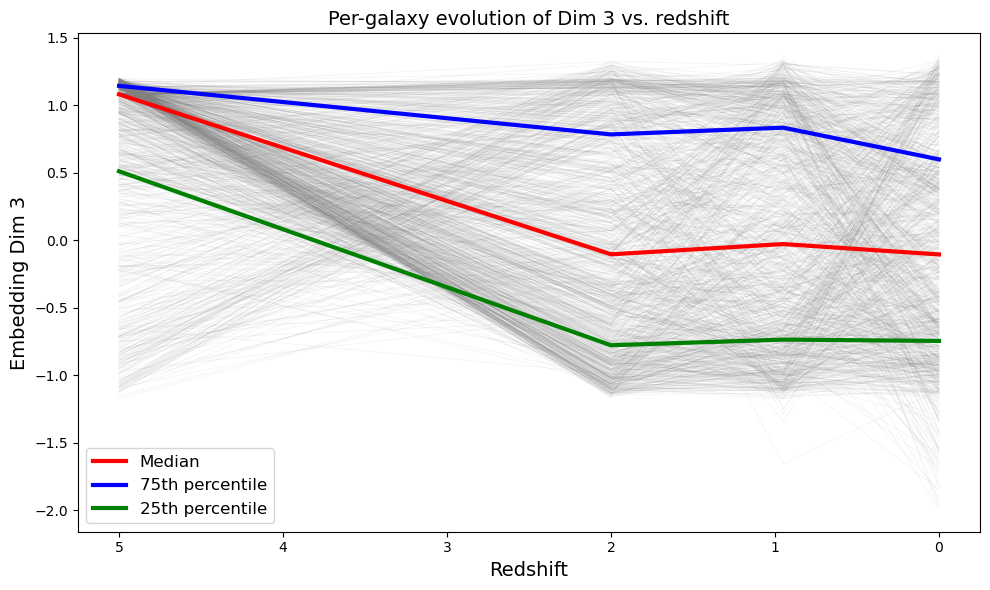

In [29]:
# Make spaghetti plot for embedding dim 3 vs. redshift
fig, ax = plt.subplots(figsize=(10, 6))
for i in range(len(tracked)):
    ax.plot(zs, traj[i, :, 2], color='gray', alpha=0.1, lw=0.5)
ax.plot(zs, np.median(traj[:, :, 2], axis=0), color='red', lw=3, label='Median')
# plot 25th and 75th percentiles
ax.plot(zs, np.percentile(traj[:, :, 2], 75, axis=0), color='blue', lw=3, label='75th percentile')
ax.plot(zs, np.percentile(traj[:, :, 2], 25, axis=0), color='green', lw=3, label='25th percentile')
ax.invert_xaxis()  # higher z on the left (earlier time)
ax.set_xlabel('Redshift', fontsize=14)
ax.set_ylabel('Embedding Dim 3', fontsize=14)
ax.set_title('Per-galaxy evolution of Dim 3 vs. redshift', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()


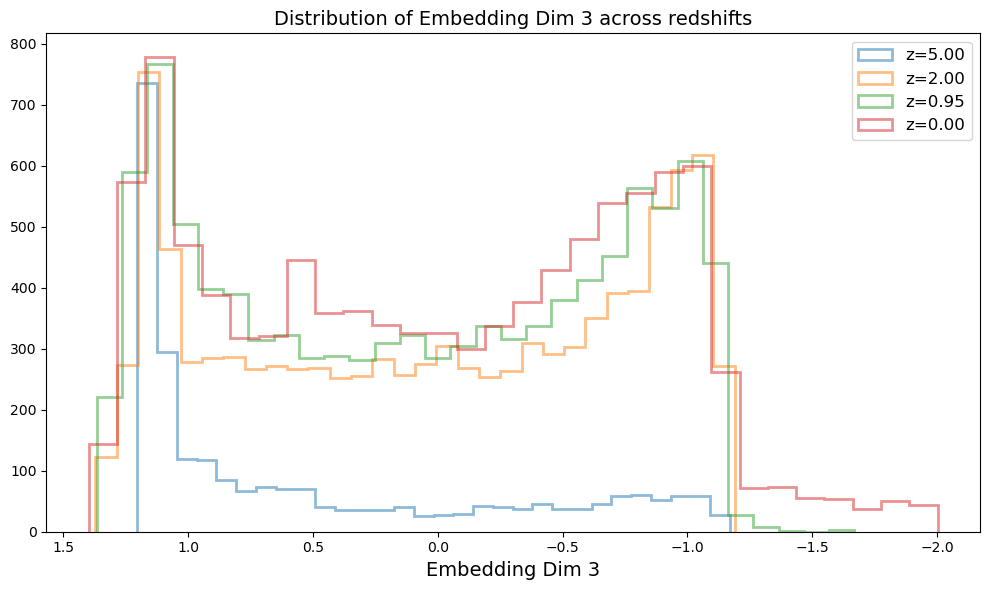

In [32]:
# Plot overlapping histograms of embedding dimension 3 for each redshift slice
fig, ax = plt.subplots(figsize=(10, 6))
for s in snaps_ordered:
    ax.hist(X[s][:, 2], bins=30, alpha=0.5, 
            label=f'z={REDSHIFTS[s]:.2f}', histtype='step', lw=2)
ax.invert_xaxis()  # higher z on the left (earlier time)
ax.set_xlabel('Embedding Dim 3', fontsize=14)
ax.set_title('Distribution of Embedding Dim 3 across redshifts', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()


## Evolution Plot 2 — Stratified by z=0 Embedding Dim 1

Mean ± standard error of the mean, for Dims 1, 2, 3 separately, stratified into tertiles of z=0 Dim 1 (Clusters / Filaments / Field).

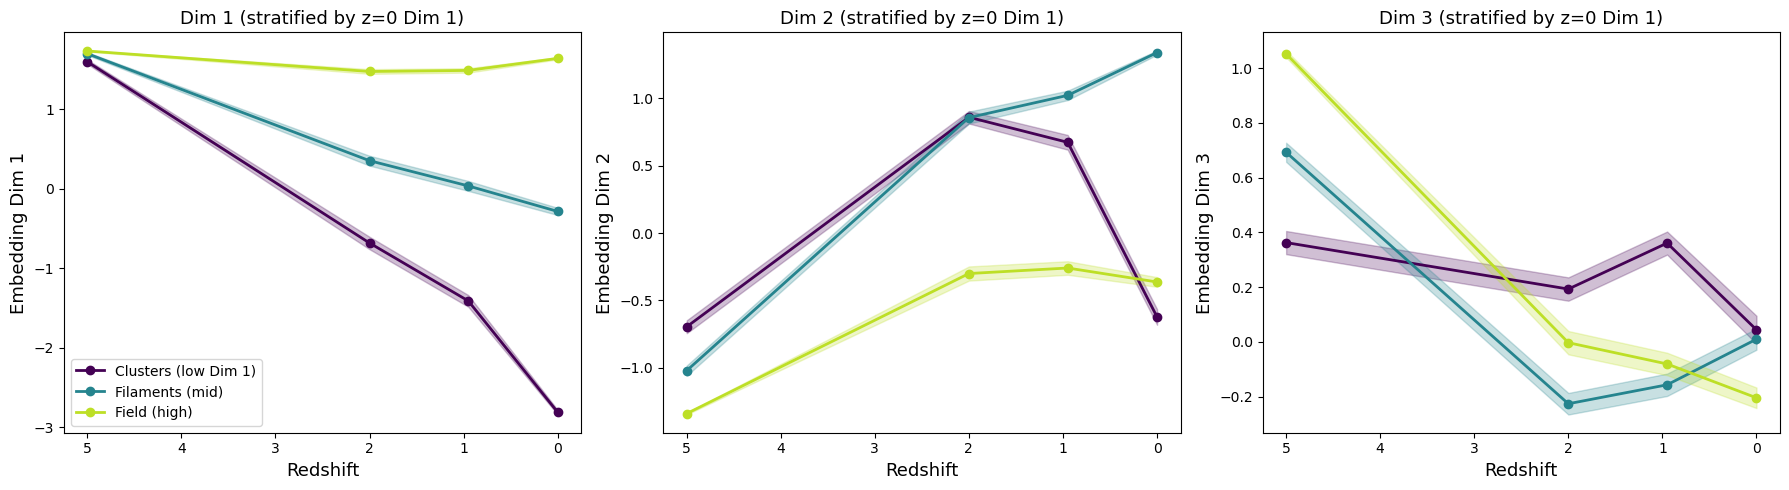

In [10]:
def plot_stratified_evolution(traj, zs, strat_values, strat_label, n_strata=3, labels=None):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    edges = np.percentile(strat_values, np.linspace(0, 100, n_strata + 1))
    bin_idx = np.clip(np.digitize(strat_values, edges) - 1, 0, n_strata - 1)
    colors = plt.cm.viridis(np.linspace(0, 0.9, n_strata))
    if labels is None:
        labels = [f'{strat_label} $\\in$ [{edges[i]:.2f}, {edges[i+1]:.2f}]' for i in range(n_strata)]
    for dim_i, ax in enumerate(axes):
        for k_strat in range(n_strata):
            sel = bin_idx == k_strat
            mu = traj[sel, :, dim_i].mean(axis=0)
            sem = traj[sel, :, dim_i].std(axis=0, ddof=1) / np.sqrt(sel.sum())
            ax.plot(zs, mu, color=colors[k_strat], marker='o', lw=2, label=labels[k_strat])
            ax.fill_between(zs, mu - sem, mu + sem, color=colors[k_strat], alpha=0.25)
        ax.invert_xaxis()
        ax.set_xlabel('Redshift', fontsize=13)
        ax.set_ylabel(f'Embedding Dim {dim_i+1}', fontsize=13)
        ax.set_title(f'Dim {dim_i+1} (stratified by {strat_label})', fontsize=13)
        if dim_i == 0:
            ax.legend(fontsize=10, loc='best')
    plt.tight_layout()
    plt.show()

# Stratify by z=0 Dim 1
z0_dim1 = traj[:, -1, 0]  # last snap is z=0 (snap 99)
plot_stratified_evolution(traj, zs, z0_dim1, 'z=0 Dim 1', n_strata=3,
                           labels=['Clusters (low Dim 1)', 'Filaments (mid)', 'Field (high)'])

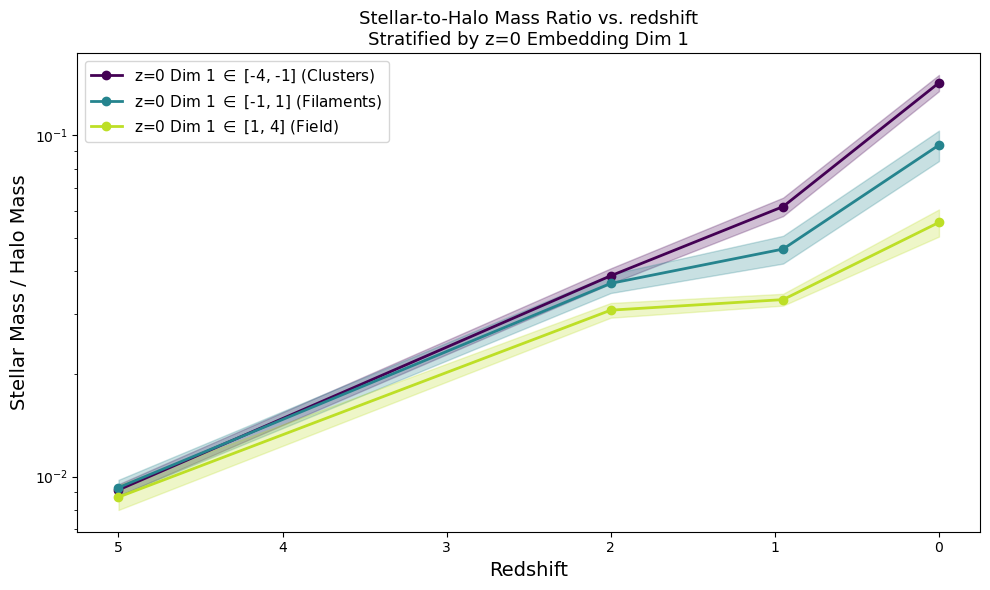

In [35]:
# Stellar-to-halo mass ratio vs. redshift, stratified by z=0 Dim 1.
# Uses mass_total (SubhaloMass = total bound subhalo mass) as the halo denominator
# to match earlier plots. Swap to 'm200' for parent-FoF M_200crit if preferred.

snaps_ordered = sorted(SNAPS)  # [17, 33, 51, 99]
zs = np.array([REDSHIFTS[s] for s in snaps_ordered])

# Build (n_tracked, n_snaps) arrays of stellar mass and halo mass for tracked galaxies.
# All values are in TNG code units (1e10 Msun/h); the ratio is unitless so we can
# leave them in code units.
props_idx = props.set_index('idx_z0')
n = len(tracked)
mstar = np.full((n, len(snaps_ordered)), np.nan)
mhalo = np.full((n, len(snaps_ordered)), np.nan)
for j, s in enumerate(snaps_ordered):
    mstar[:, j] = props_idx.loc[tracked, f'mass_stars_snap_{s}'].to_numpy(dtype=float)
    mhalo[:, j] = props_idx.loc[tracked, f'mass_total_snap_{s}'].to_numpy(dtype=float)

with np.errstate(divide='ignore', invalid='ignore'):
    ratio = mstar / mhalo  # (n_tracked, n_snaps)
ratio[~np.isfinite(ratio) | (mhalo <= 0)] = np.nan

# Stratify by z=0 Dim 1
z0_dim1 = traj[:, -1, 0]
z0_bin_edges = [-4, -1, 1, 4]
n_strata = 3
z0_bin_indices = np.clip(np.digitize(z0_dim1, z0_bin_edges) - 1, 0, n_strata - 1)
labels = ["Clusters", "Filaments", "Field"]
z0_bin_labels = [f'z=0 Dim 1 $\\in$ [{z0_bin_edges[i]}, {z0_bin_edges[i+1]}] ({labels[i]})'
                 for i in range(n_strata)]
colors = plt.cm.viridis(np.linspace(0, 0.9, n_strata))

fig, ax = plt.subplots(figsize=(10, 6))
for i in range(n_strata):
    sel = z0_bin_indices == i
    r = ratio[sel, :]  # shape (n_in_stratum, n_snaps)
    means = np.nanmean(r, axis=0)
    counts = np.sum(~np.isnan(r), axis=0)
    sems = np.nanstd(r, axis=0, ddof=1) / np.sqrt(counts)
    ax.plot(zs, means, color=colors[i], marker='o', lw=2, label=z0_bin_labels[i])
    ax.fill_between(zs, means - sems, means + sems, color=colors[i], alpha=0.25)

ax.invert_xaxis()
ax.set_xlabel('Redshift', fontsize=14)
ax.set_yscale('log')
ax.set_ylabel('Stellar Mass / Halo Mass', fontsize=14)
ax.set_title('Stellar-to-Halo Mass Ratio vs. redshift\nStratified by z=0 Embedding Dim 1', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


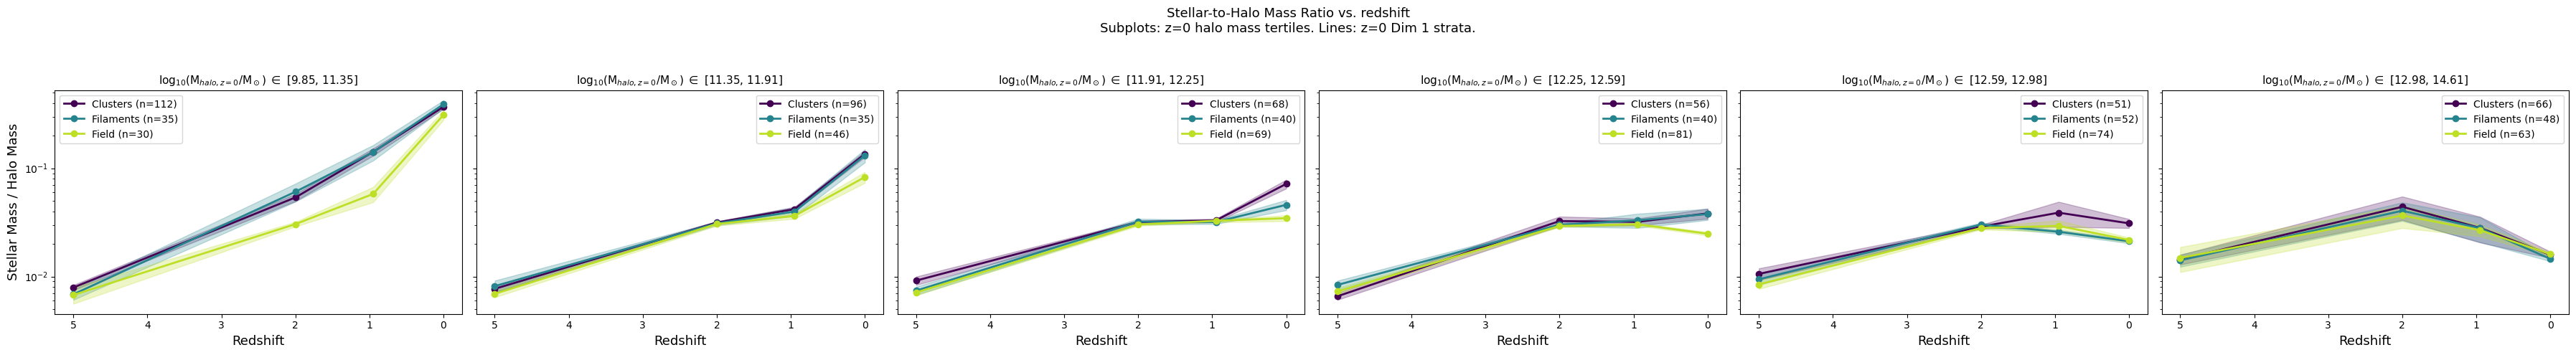

In [38]:
# Stellar-to-halo mass ratio vs. redshift, stratified by z=0 Dim 1 within
# subplots that are themselves stratified by z=0 halo mass.

snaps_ordered = sorted(SNAPS)  # [17, 33, 51, 99]
zs = np.array([REDSHIFTS[s] for s in snaps_ordered])

# Pull stellar + halo masses across all 4 snapshots for tracked galaxies
props_idx = props.set_index('idx_z0')
n = len(tracked)
mstar = np.full((n, len(snaps_ordered)), np.nan)
mhalo = np.full((n, len(snaps_ordered)), np.nan)
for j, s in enumerate(snaps_ordered):
    mstar[:, j] = props_idx.loc[tracked, f'mass_stars_snap_{s}'].to_numpy(dtype=float)
    mhalo[:, j] = props_idx.loc[tracked, f'mass_total_snap_{s}'].to_numpy(dtype=float)

with np.errstate(divide='ignore', invalid='ignore'):
    ratio = mstar / mhalo
ratio[~np.isfinite(ratio) | (mhalo <= 0)] = np.nan

# z=0 stratifiers
z0_dim1 = traj[:, -1, 0]
z0_mhalo = mhalo[:, -1]  # halo mass at snap 99

# Inner stratification: z=0 Dim 1 (clusters/filaments/field)
dim1_edges = [-4, -1, 1, 4]
n_dim1 = 3
dim1_idx = np.clip(np.digitize(z0_dim1, dim1_edges) - 1, 0, n_dim1 - 1)
dim1_labels = ['Clusters', 'Filaments', 'Field']
dim1_colors = plt.cm.viridis(np.linspace(0, 0.9, n_dim1))

# Outer stratification: z=0 halo mass tertiles (log scale handles skew)
log_mh = np.log10(np.where(z0_mhalo > 0, z0_mhalo, np.nan))
n_mh = 6
valid_mh = ~np.isnan(log_mh)
mh_edges = np.nanpercentile(log_mh, np.linspace(0, 100, n_mh + 1))
mh_idx = np.clip(np.digitize(log_mh, mh_edges) - 1, 0, n_mh - 1)
mh_idx[~valid_mh] = -1  # mark invalid
# Convert tertile edges from code units (log10(1e10 Msun/h)) to Msun for labels
mh_edges_msun_log = mh_edges + np.log10(1e10 / H)
mh_titles = [f'log$_{{10}}$(M$_{{halo,z=0}}$/M$_\\odot$) $\\in$ '
             f'[{mh_edges_msun_log[i]:.2f}, {mh_edges_msun_log[i+1]:.2f}]'
             for i in range(n_mh)]

fig, axes = plt.subplots(1, n_mh, figsize=(6 * n_mh, 5), sharey=True)
for k, ax in enumerate(axes):
    in_mh_bin = (mh_idx == k)
    for i in range(n_dim1):
        sel = in_mh_bin & (dim1_idx == i)
        if sel.sum() == 0:
            continue
        r = ratio[sel, :]
        means = np.nanmean(r, axis=0)
        counts = np.sum(~np.isnan(r), axis=0)
        # Avoid division by zero for empty snapshot bins
        sems = np.where(counts > 1,
                        np.nanstd(r, axis=0, ddof=1) / np.sqrt(np.maximum(counts, 1)),
                        np.nan)
        ax.plot(zs, means, color=dim1_colors[i], marker='o', lw=2,
                label=f'{dim1_labels[i]} (n={sel.sum()})')
        ax.fill_between(zs, means - sems, means + sems,
                        color=dim1_colors[i], alpha=0.25)
    ax.invert_xaxis()
    ax.set_xlabel('Redshift', fontsize=13)
    ax.set_title(mh_titles[k], fontsize=11)
    ax.set_yscale('log')
    ax.legend(fontsize=10)
axes[0].set_ylabel('Stellar Mass / Halo Mass', fontsize=13)
fig.suptitle('Stellar-to-Halo Mass Ratio vs. redshift\n'
             'Subplots: z=0 halo mass tertiles. Lines: z=0 Dim 1 strata.', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


## Evolution Plot 3 — Stratified by z=0 Stellar Mass

Same idea, but tertiles of present-day stellar mass.

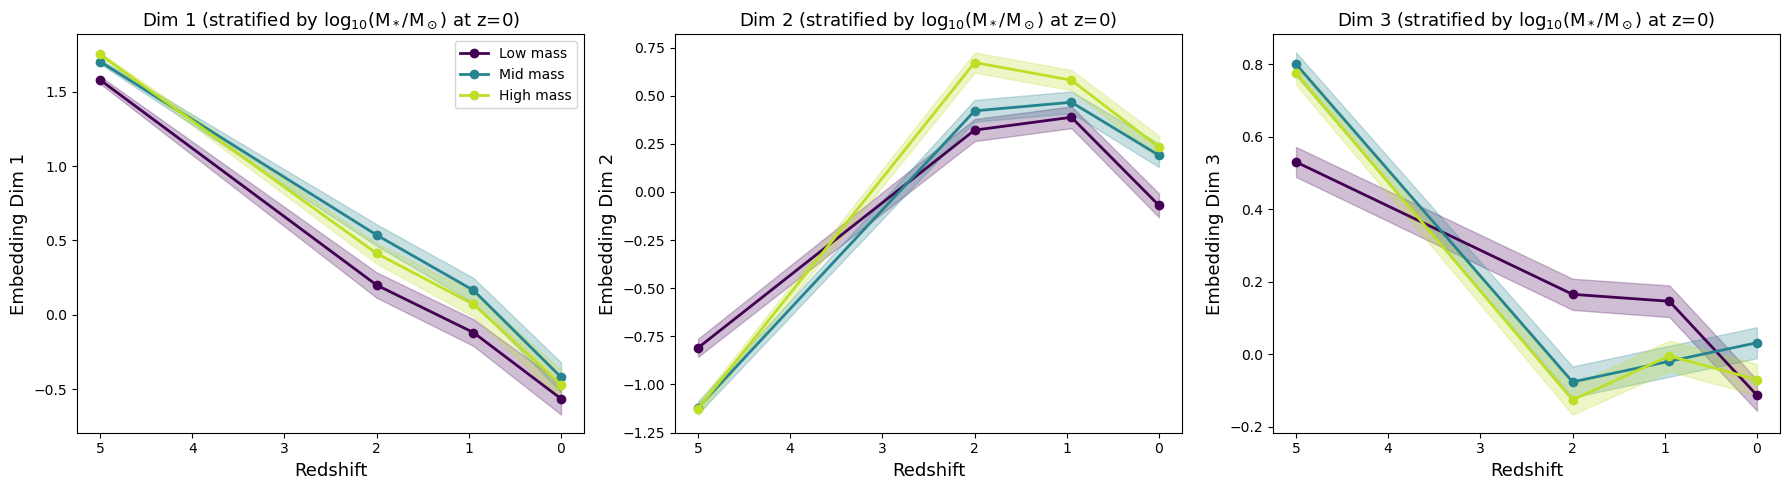

In [11]:
# Align properties to the tracked subset
props_idx = props.set_index('idx_z0')
mass_z0 = props_idx.loc[tracked, 'mass_stars_snap_99'].to_numpy() * 1e10 / H  # in M_sun
log_mass = np.log10(mass_z0)
plot_stratified_evolution(traj, zs, log_mass, 'log$_{10}$(M$_*$/M$_\\odot$) at z=0', n_strata=3,
                           labels=['Low mass', 'Mid mass', 'High mass'])

## Evolution Plot 4 — 2D Trajectories in (Dim 1, Dim 2) Space

Sub-sample of galaxies showing their projected paths from z=5 → z=0 in the (Dim 1, Dim 2) plane. Each arrow connects consecutive snapshots; the dot marks the z=0 position.

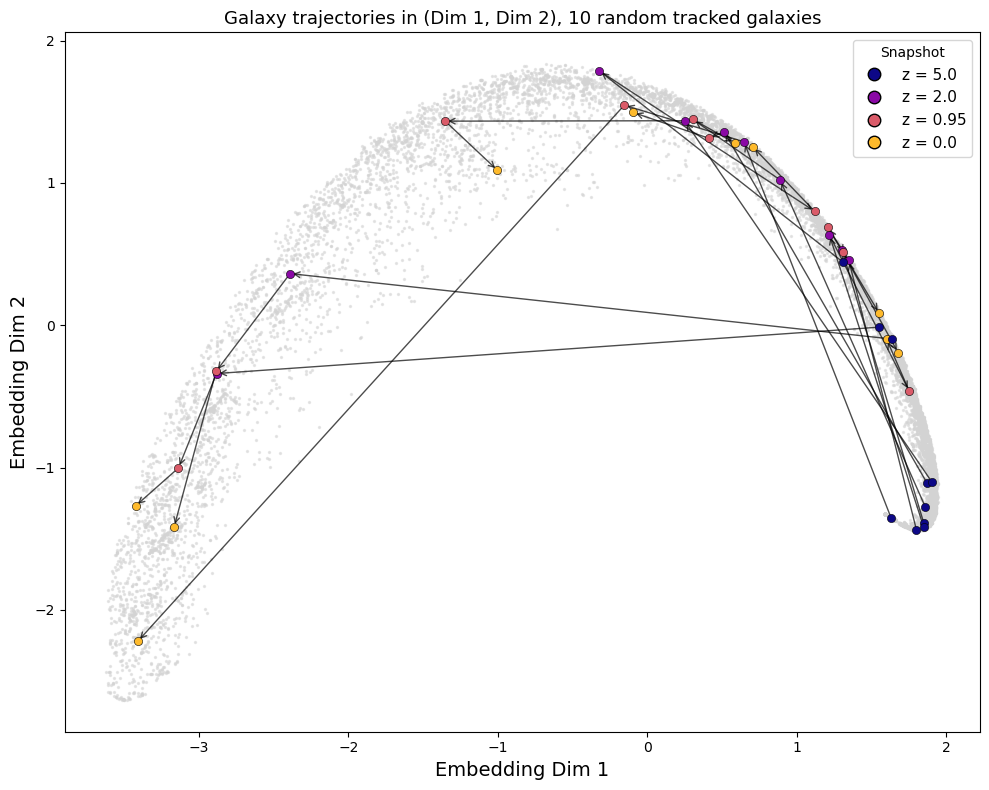

In [42]:
rng = np.random.default_rng(0)
subset = rng.choice(len(tracked), 10, replace=False)

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X[99][:, 0], X[99][:, 1], s=2, alpha=0.5, color='lightgray', label='All z=0 galaxies')

# One color per snapshot (not per transition)
snap_colors = plt.cm.plasma(np.linspace(0, 0.85, len(snaps_ordered)))

for i in subset:
    pts = traj[i, :, :2]
    # Arrows in neutral gray so the colored dots stand out
    for j in range(len(snaps_ordered) - 1):
        ax.annotate('', xy=pts[j+1], xytext=pts[j],
                    arrowprops=dict(arrowstyle='->', color='k', alpha=0.7, lw=1.0))
    # One dot per snapshot, colored by snapshot
    for j, s in enumerate(snaps_ordered):
        ax.scatter(*pts[j], s=35, color=snap_colors[j],
                   edgecolors='black', linewidths=0.4, zorder=5)

# Legend: one entry per snapshot
from matplotlib.lines import Line2D
legend_dots = [Line2D([0], [0], marker='o', color='w', markerfacecolor=snap_colors[j],
                      markeredgecolor='black', markersize=9,
                      label=f'z = {REDSHIFTS[s]}')
               for j, s in enumerate(snaps_ordered)]
ax.legend(handles=legend_dots, fontsize=11, title='Snapshot')

ax.set_xlabel('Embedding Dim 1', fontsize=14)
ax.set_ylabel('Embedding Dim 2', fontsize=14)
ax.set_title('Galaxy trajectories in (Dim 1, Dim 2), 10 random tracked galaxies', fontsize=13)
plt.tight_layout()
plt.show()


## Embedding–Property Relationships

At each snapshot, plot the *projected* embedding dimensions vs. the physical property at the same snapshot. Each property gets one figure: rows = Dims 1/2/3, columns = snapshots (z=5, 2, 0.95, 0). Scatter is faint; red line is the running median.

In [13]:
def running_median(x, y, n_bins=15, min_count=5):
    if len(x) == 0:
        return np.array([]), np.array([])
    edges = np.linspace(x.min(), x.max(), n_bins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    med = np.full(n_bins, np.nan)
    for i in range(n_bins):
        m = (x >= edges[i]) & (x < edges[i+1])
        if m.sum() >= min_count:
            med[i] = np.median(y[m])
    ok = ~np.isnan(med)
    return centers[ok], med[ok]

# Property descriptors: (column-prefix, axis-label, transform)
def log10_safe(arr):
    return np.log10(np.clip(arr, 1e-30, None))

PROPS = [
    ('sfr',         'log$_{10}$(SFR / [M$_\\odot$/yr])',         log10_safe),
    ('mass_stars',  'log$_{10}$(M$_*$/M$_\\odot$)',                lambda a: log10_safe(a * 1e10 / H)),
    ('mass_total',  'log$_{10}$(M$_{tot}$/M$_\\odot$)',            lambda a: log10_safe(a * 1e10 / H)),
    ('m200',        'log$_{10}$(M$_{200}$/M$_\\odot$)',            lambda a: log10_safe(a * 1e10 / H)),
    ('starmet',     'Stellar metallicity (mass fraction)',         lambda a: a),
    ('gasmet',      'Gas metallicity (mass fraction)',             lambda a: a),
]

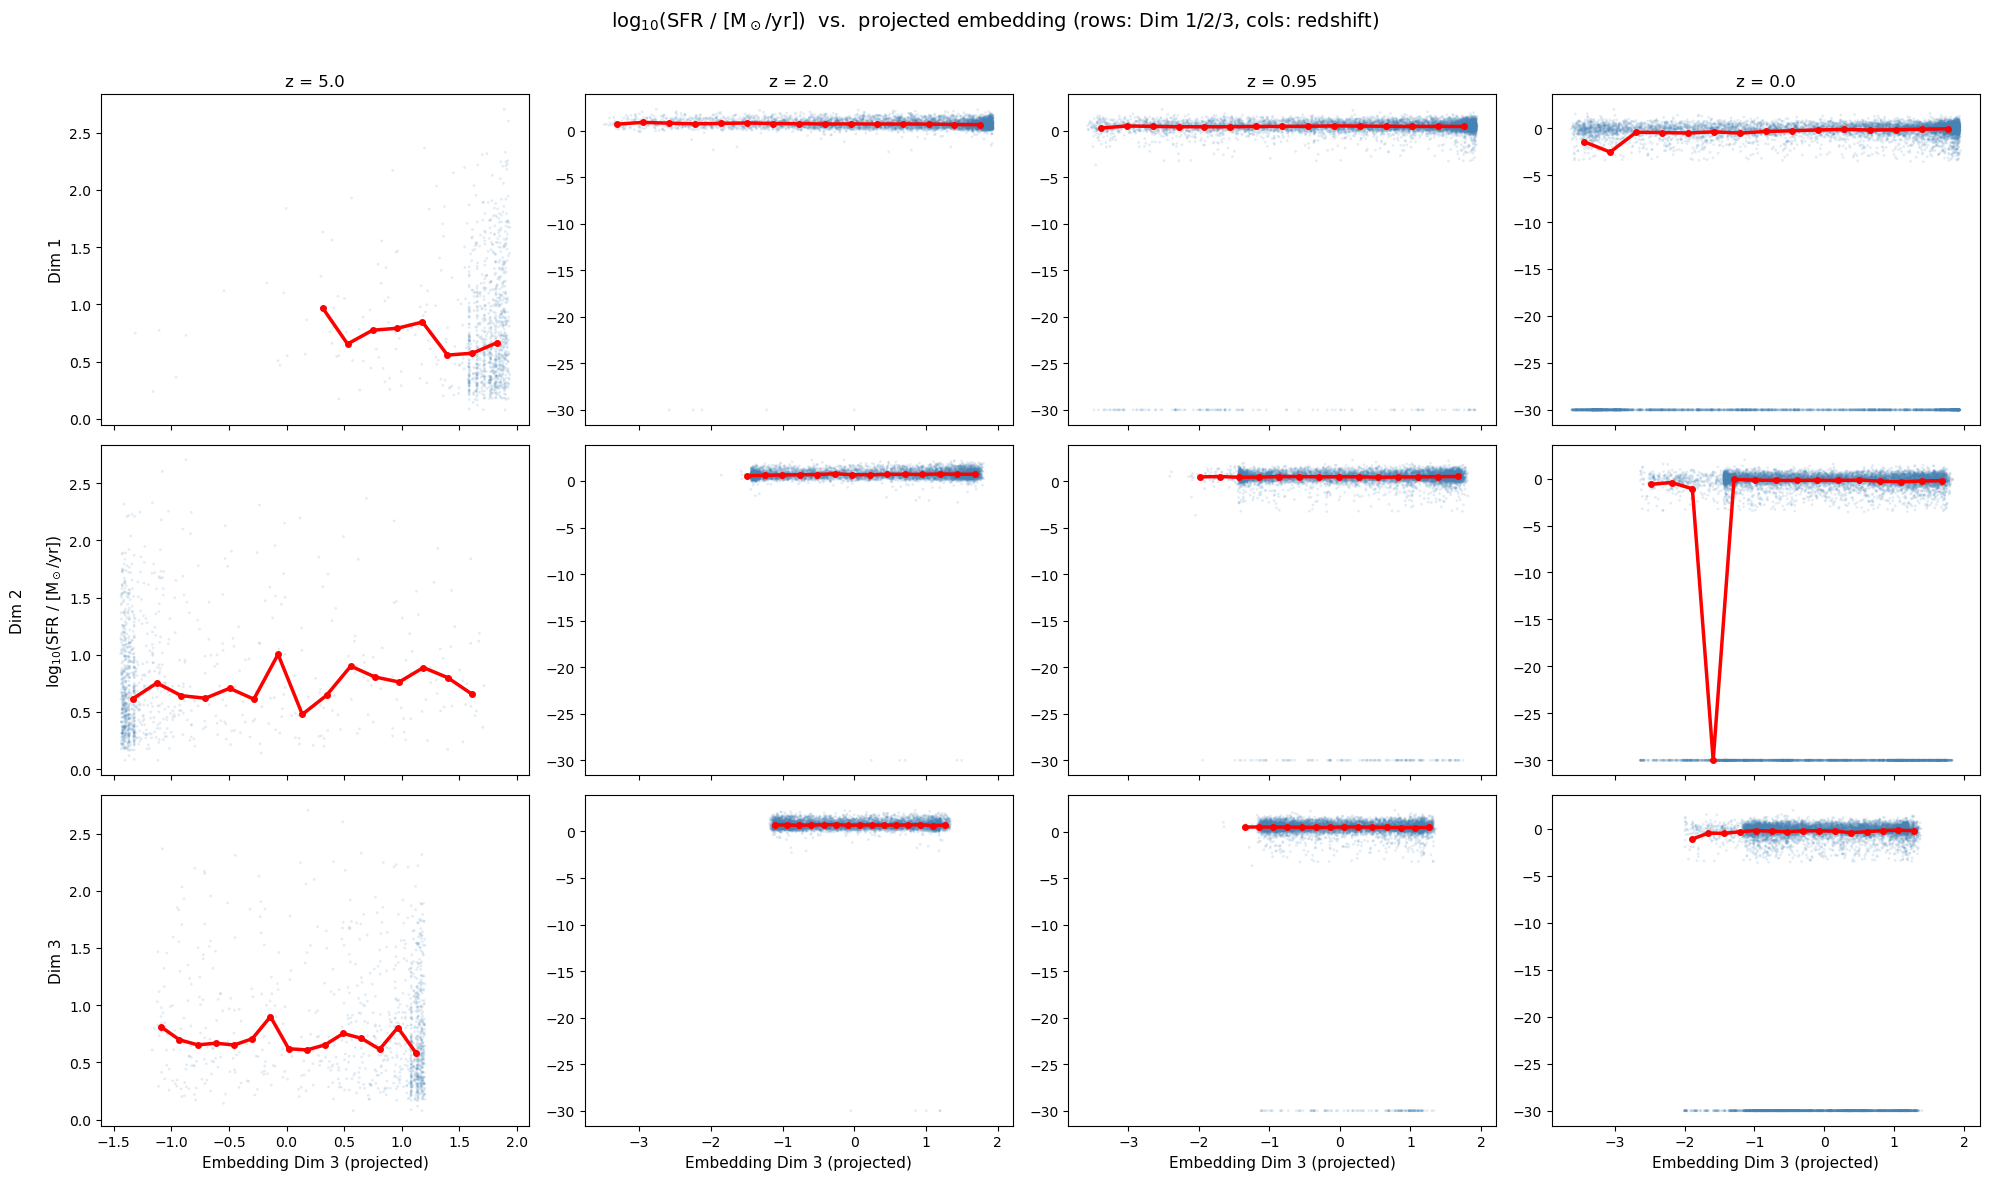

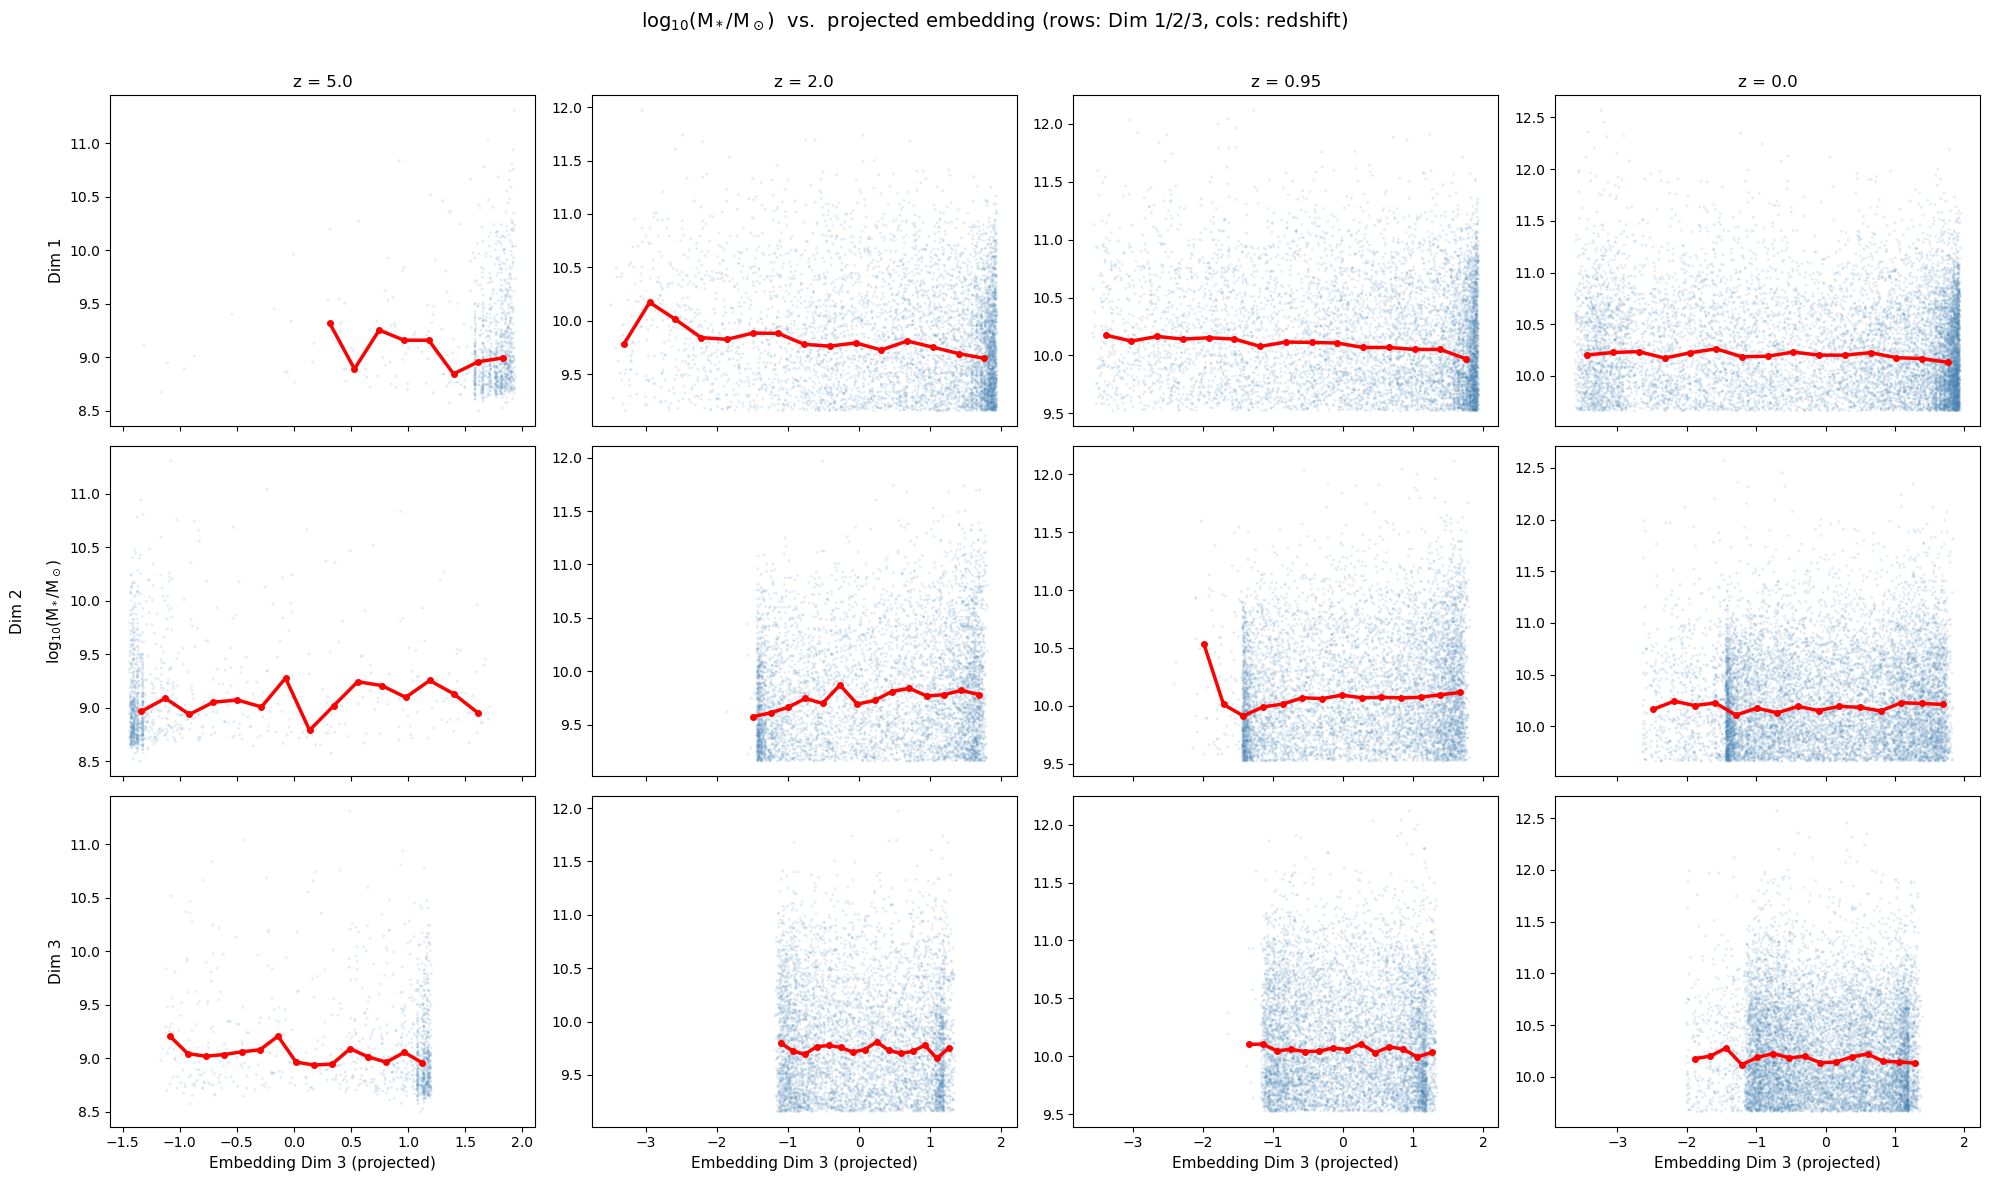

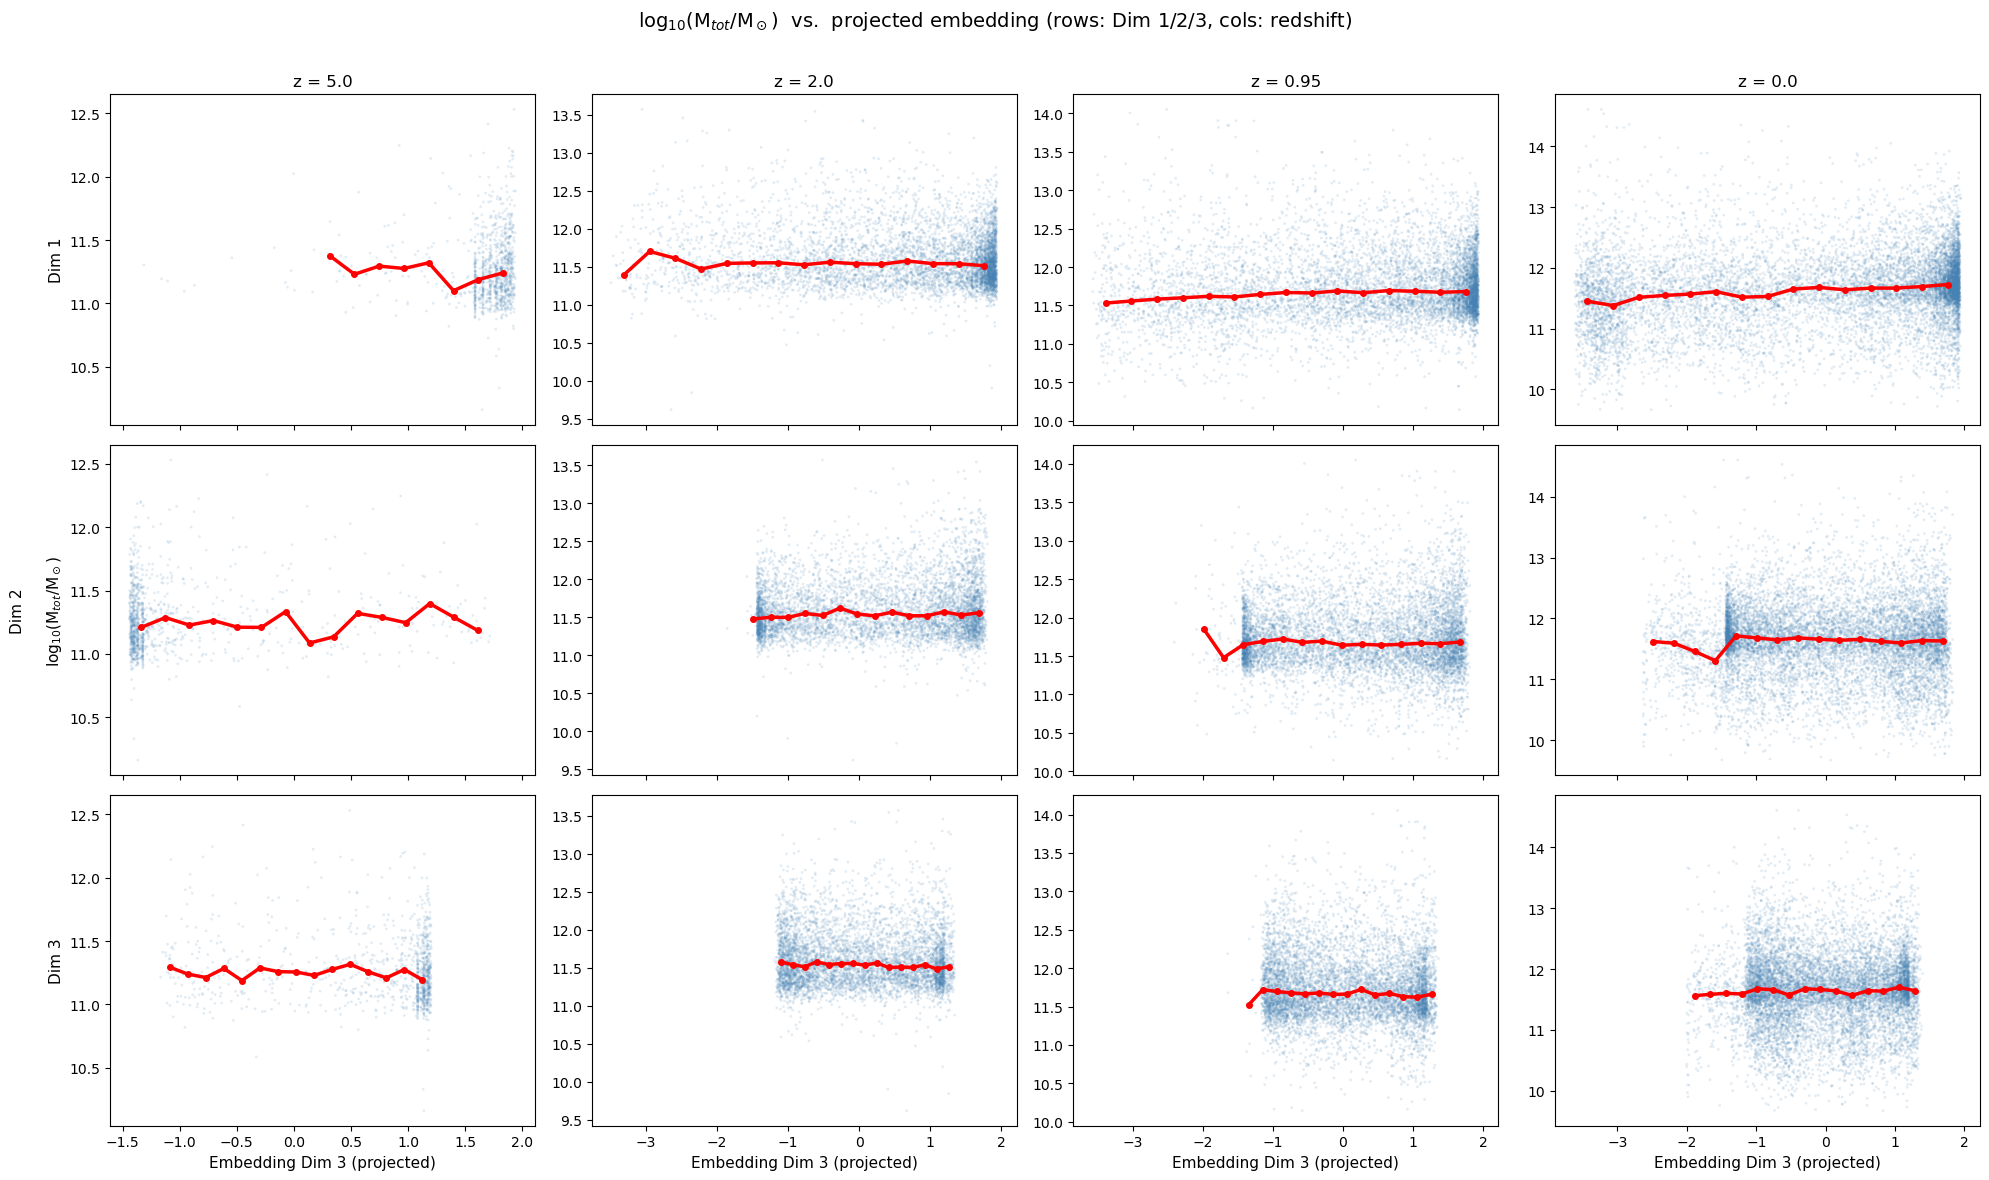

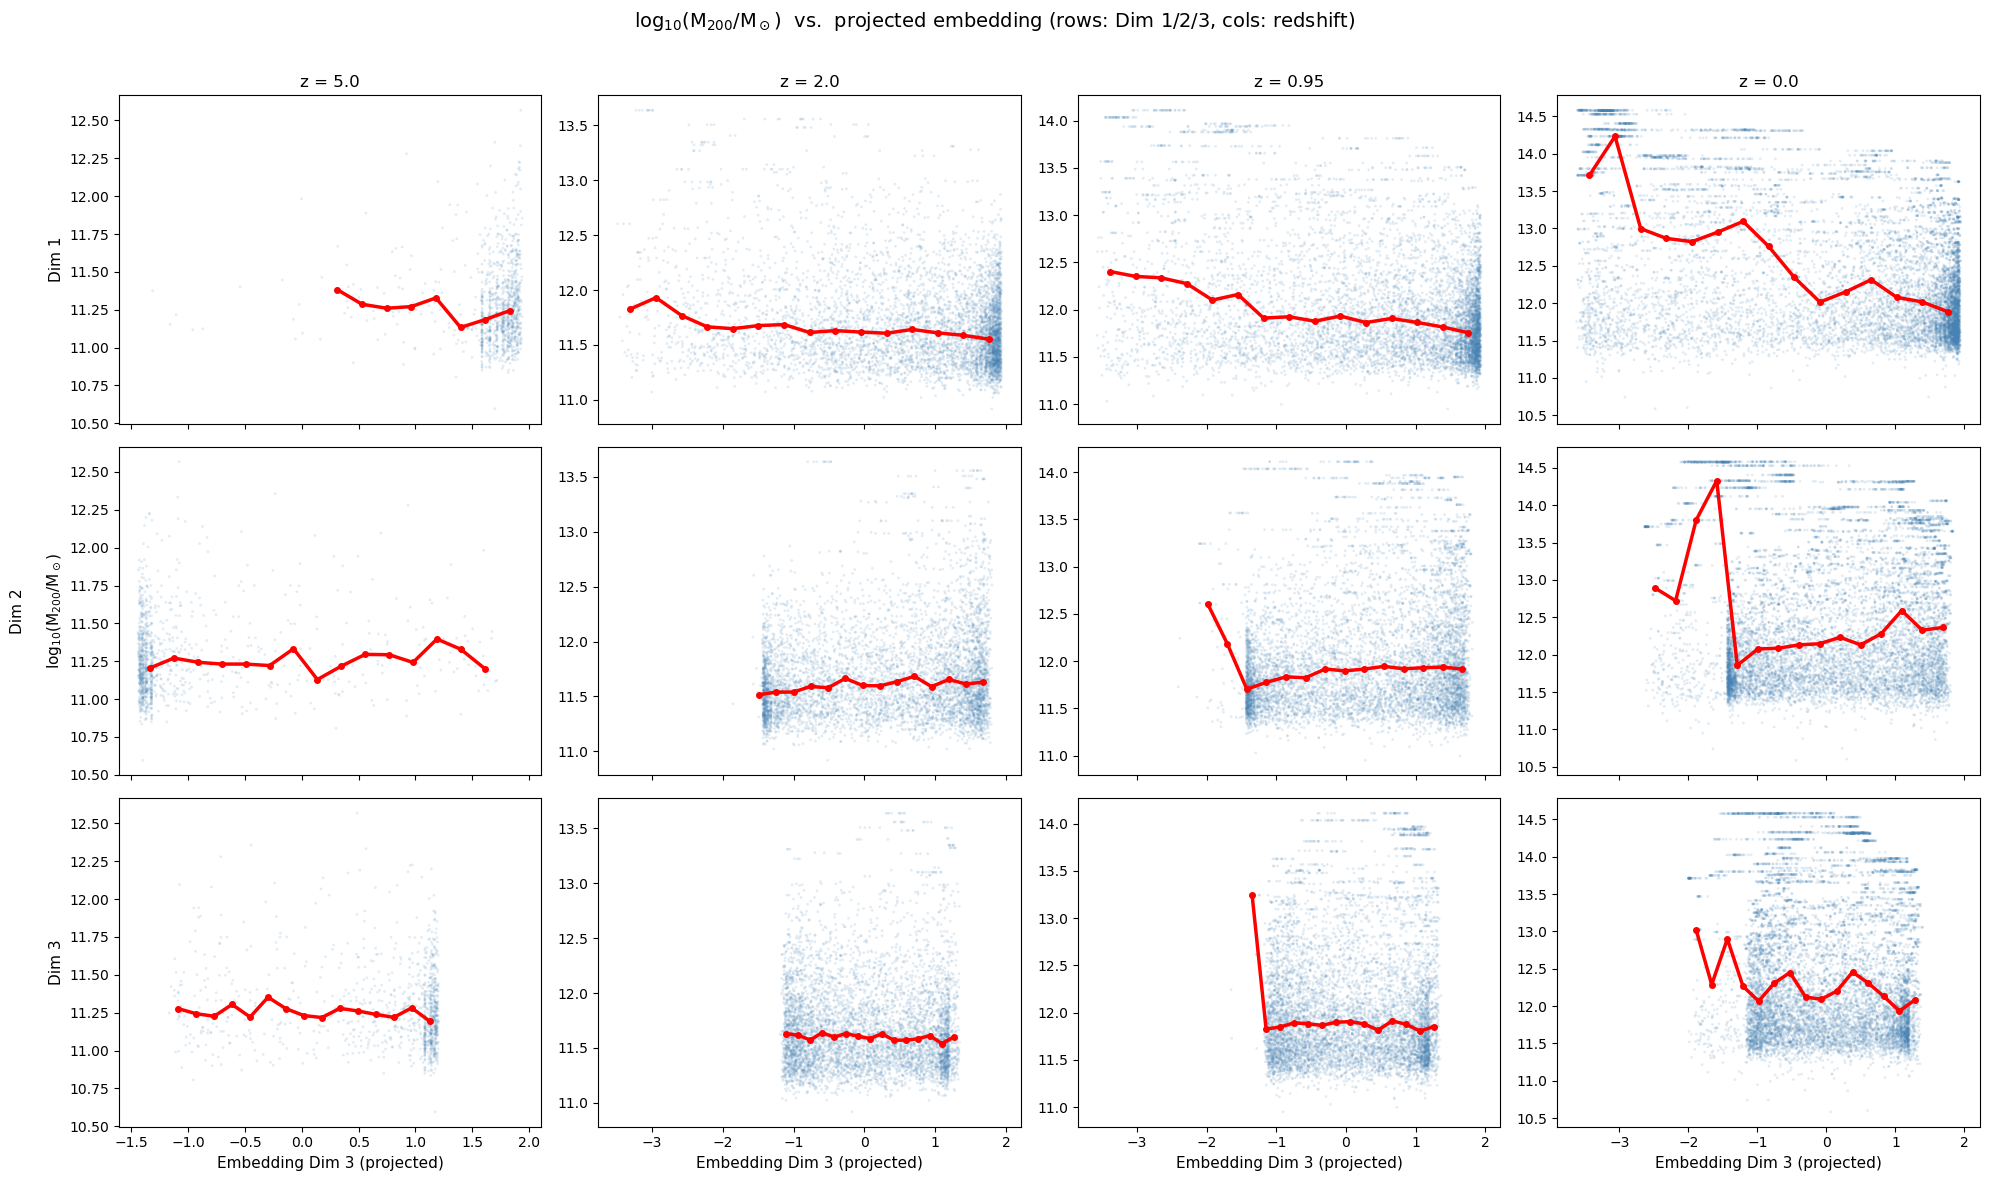

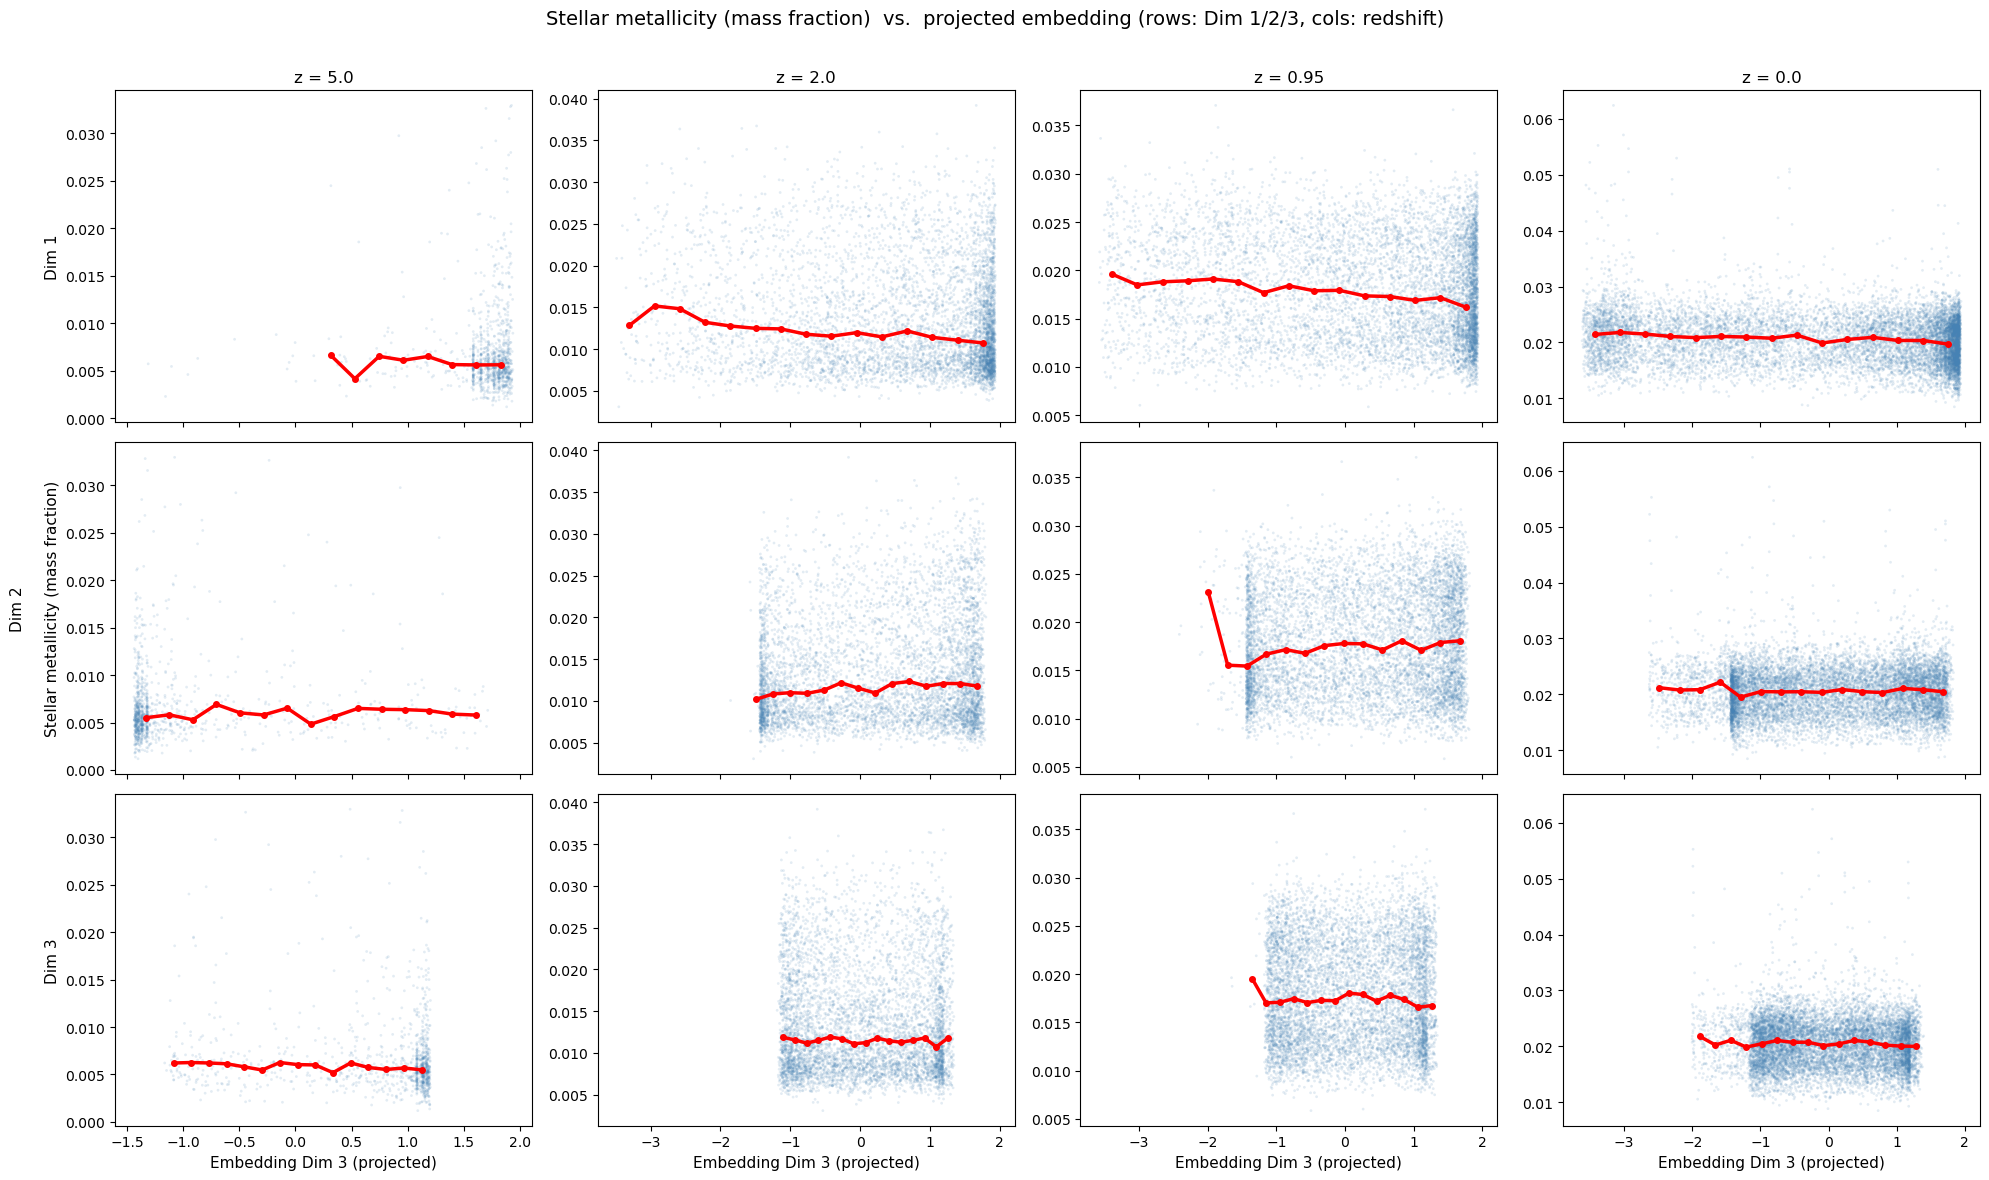

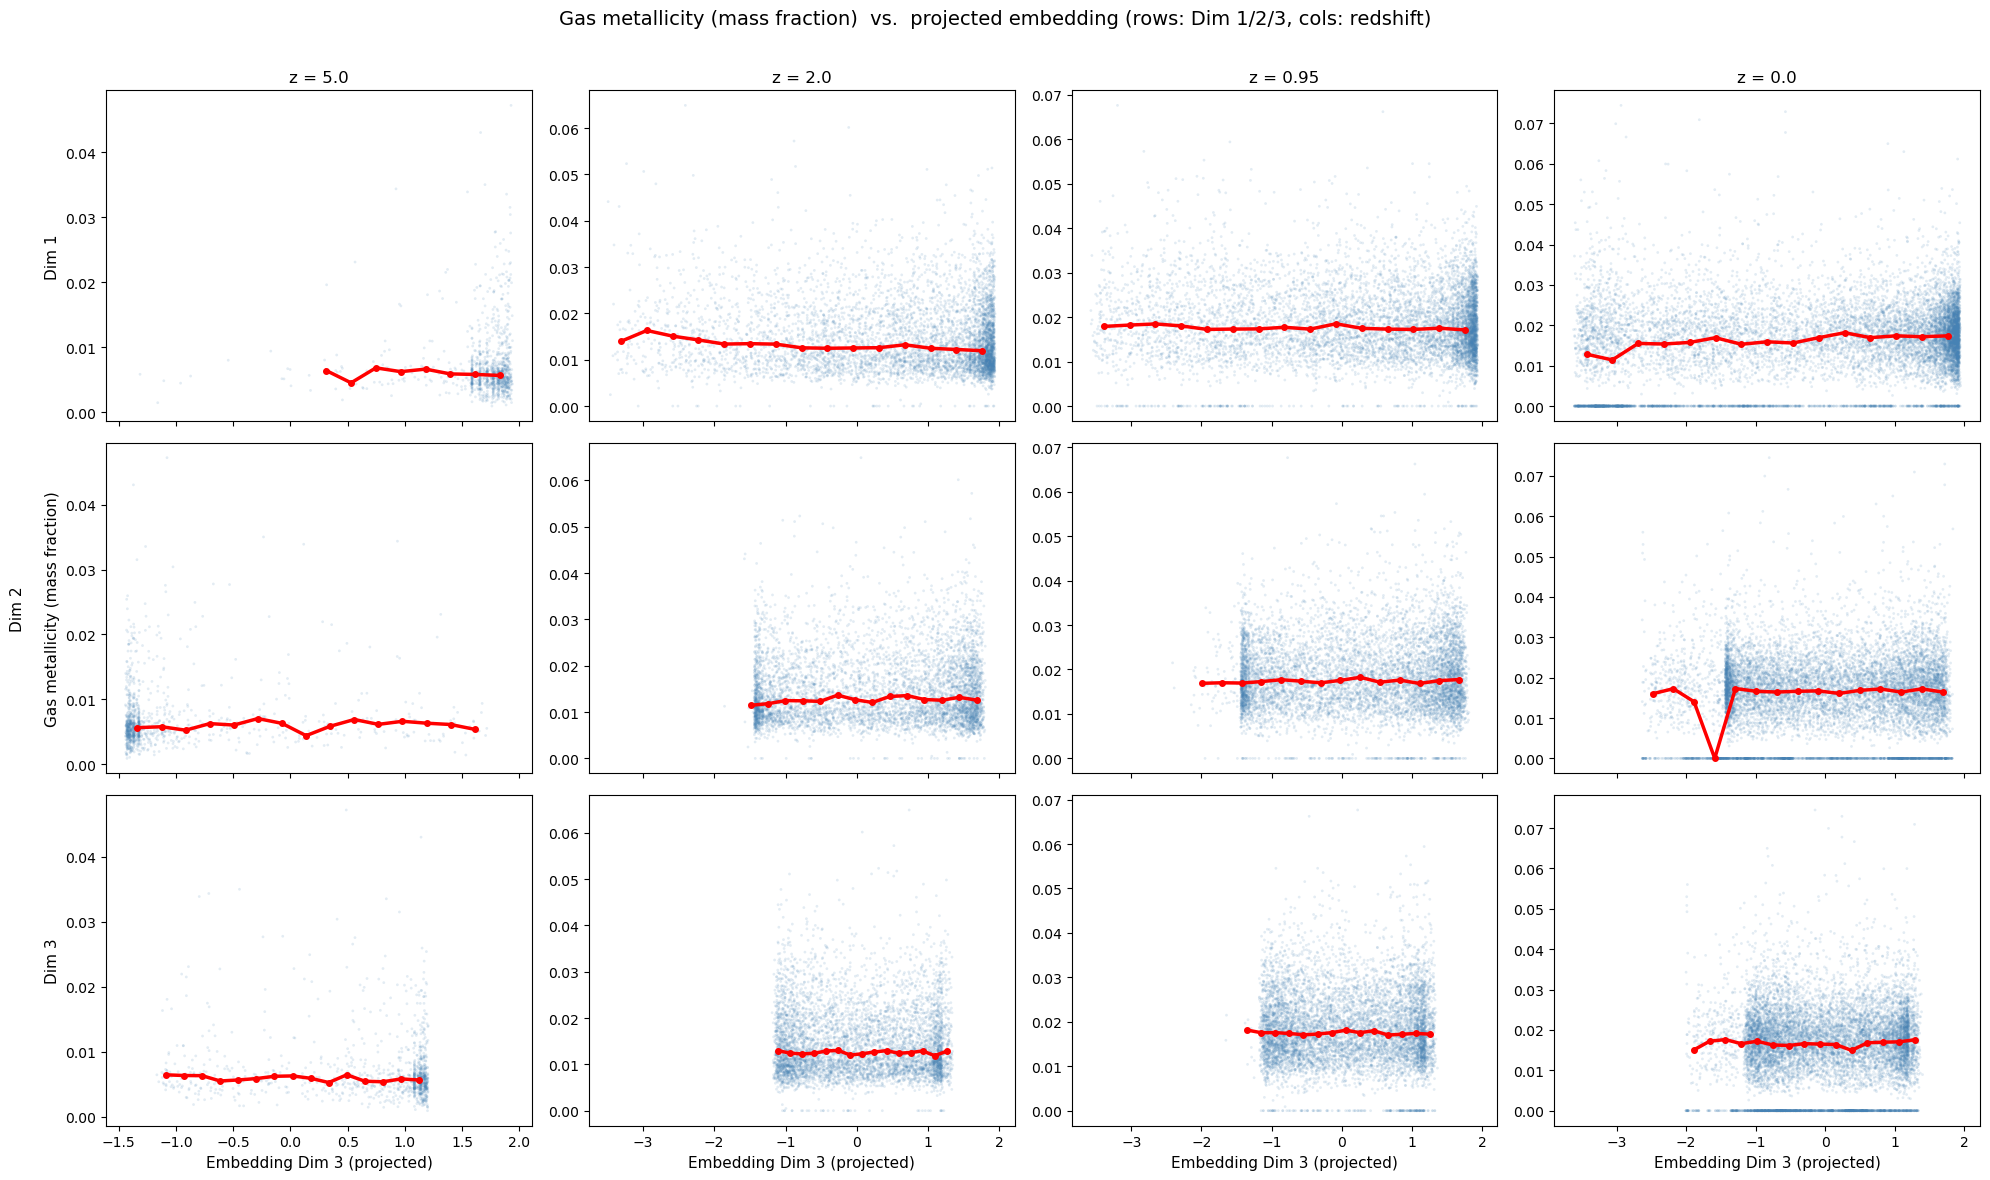

In [14]:
for prefix, ylabel, transform in PROPS:
    fig, axes = plt.subplots(3, 4, figsize=(20, 12), sharex='col')
    for col, s in enumerate(snaps_ordered):
        # For each snapshot, get the galaxies that have BOTH a projected embedding
        # at this snap and a property value at this snap.
        valid = row_at[s] >= 0
        col_name = f'{prefix}_snap_{s}'
        if col_name not in props.columns:
            for row in range(3):
                axes[row, col].set_visible(False)
            continue
        prop_vals = props.loc[valid, col_name].to_numpy(dtype=float)
        keep = ~np.isnan(prop_vals) & np.isfinite(prop_vals)
        prop_t = transform(prop_vals[keep])
        idx_z0_valid = np.where(valid)[0][keep]
        emb_rows = row_at[s][idx_z0_valid]
        for row in range(3):
            ax = axes[row, col]
            x = X[s][emb_rows, row]
            ax.scatter(x, prop_t, s=4, alpha=0.15, color='steelblue', edgecolors='none')
            cx, cy = running_median(x, prop_t)
            if len(cx):
                ax.plot(cx, cy, color='red', lw=2.5, marker='o', markersize=4)
            if col == 0:
                ax.set_ylabel(f'Dim {row+1}\n\n{ylabel}' if row == 1 else f'Dim {row+1}', fontsize=11)
            if row == 0:
                ax.set_title(f'z = {REDSHIFTS[s]}', fontsize=12)
            if row == 2:
                ax.set_xlabel(f'Embedding Dim {row+1} (projected)', fontsize=11)
    fig.suptitle(f'{ylabel}  vs.  projected embedding (rows: Dim 1/2/3, cols: redshift)', fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()